[*********************100%***********************]  1 of 1 completed


RMSE: 0.01271068826102913
MAE: 0.00799075227651656
R2: -0.2415403013876598
Residual Mean: -0.0001421528538661283
Residual Std: 0.012713971595729684
Sharpe Ratio: 0.5737693386181627
Max Drawdown: -0.07711736672359981


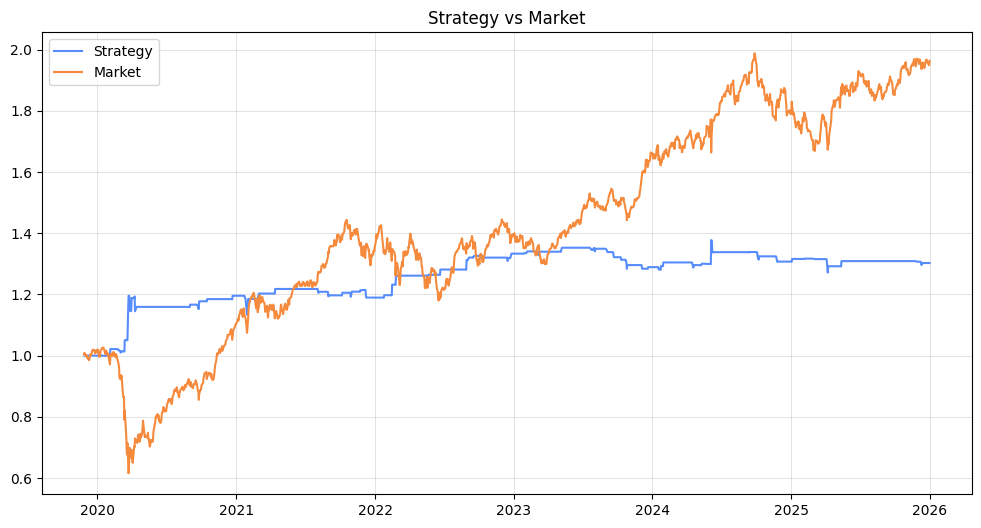

In [1]:
# -------------------------------
# 1. IMPORT LIBRARIES
# -------------------------------

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


# -------------------------------
# 2. DOWNLOAD DATA
# -------------------------------

# Download NIFTY 50 index data
df = yf.download("^NSEI",
                 start="2019-06-06",
                 end="2026-01-01",
                 auto_adjust=False,
                 multi_level_index=False)

# Keep only adjusted close (clean price)
df = df[['Adj Close']]


# -------------------------------
# 3. FEATURE ENGINEERING
# -------------------------------

# Log returns → makes data more stable (stationary)
df['returns'] = np.log(df['Adj Close'] / df['Adj Close'].shift(1))

# Lagged return (previous day info)
df['lag1'] = df['returns'].shift(1)

# Rolling mean (momentum signal)
# shift(1) → IMPORTANT to avoid using today's data
df['ma_5'] = df['returns'].rolling(5).mean().shift(1)

# Rolling volatility (risk / uncertainty)
df['volatility_5'] = df['returns'].rolling(15).std().shift(1)

# Remove missing values created due to shifting
df.dropna(inplace=True)


# -------------------------------
# 4. DEFINE FEATURES & TARGET
# -------------------------------

# X → inputs to model
x = df[['lag1', 'ma_5', 'volatility_5']]

# y → what we want to predict
y = df['returns']


# -------------------------------
# 5. ROLLING REGRESSION (NO LOOK-AHEAD)
# -------------------------------

window = 50   # number of past days used for training

forecast = []  # predicted returns
coef = []      # model coefficients (for analysis)
dates = []     # corresponding dates

for i in range(window, len(df)):

    # Training data → past 50 days
    x_train = x.iloc[i-window:i]
    y_train = y.iloc[i-window:i]

    # Test data → next day (1-step ahead prediction)
    x_test = x.iloc[i:i+1]

    # Train model
    model = LinearRegression().fit(x_train, y_train)

    # Predict next return
    prediction = model.predict(x_test)[0]

    # Store results
    forecast.append(prediction)
    coef.append(model.coef_)
    dates.append(x_test.index[0])


# -------------------------------
# 6. CREATE RESULTS DATAFRAME
# -------------------------------

results = pd.DataFrame({'pred': forecast}, index=dates)

# Actual returns for comparison
results['actual'] = df.loc[results.index, 'returns']

# Residual = prediction error = mispricing
results['residual'] = results['actual'] - results['pred']


# -------------------------------
# 7. MODEL PERFORMANCE
# -------------------------------

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse  = mean_squared_error(results['actual'], results['pred'])
mae  = mean_absolute_error(results['actual'], results['pred'])
rmse = np.sqrt(mse)
r2   = r2_score(results['actual'], results['pred'])

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

# Residual stats → important for trading
print("Residual Mean:", results['residual'].mean())
print("Residual Std:", results['residual'].std())


# -------------------------------
# 8. CREATE Z-SCORE (TRADING SIGNAL)
# -------------------------------

# Rolling normalization → adapts to changing market
roll_mean = results['residual'].rolling(50).mean()
roll_std = results['residual'].rolling(50).std()

# Z-score → how extreme current mispricing is
z = (results['residual'] - roll_mean) / roll_std

# Add to dataframe
results['z'] = z

# Remove NaNs created by rolling
results.dropna(inplace=True)


# -------------------------------
# 9. TRADING LOGIC (STATE MACHINE)
# -------------------------------

entry = 2    # enter trade when extreme
exit = 0.5   # exit when normal

pos = 0      # current position (0=no trade, 1=long, -1=short)
positions = []

for val in results['z']:

    if pos == 0:  # not in market
        if val < -entry:
            pos = 1   # LONG → price too low (expect rise)
        elif val > entry:
            pos = -1  # SHORT → price too high (expect fall)

    elif pos == 1:  # long position
        if val > -exit:
            pos = 0   # exit when normalized

    elif pos == -1:  # short position
        if val < exit:
            pos = 0

    positions.append(pos)

# Convert to series
positions = pd.Series(positions, index=results.index)


# -------------------------------
# 10. STRATEGY RETURNS
# -------------------------------

# IMPORTANT: shift(1) → trade happens next day (realistic)
strategy_returns = positions.shift(1) * results['actual']

# Add transaction cost (very important)
cost = 0.0005
strategy_returns = strategy_returns - cost * positions.diff().abs()

# Cumulative performance
cum_returns = (1 + strategy_returns).cumprod()


# -------------------------------
# 11. PERFORMANCE METRICS
# -------------------------------

sharpe = np.mean(strategy_returns) / np.std(strategy_returns) * np.sqrt(252)
max_dd = (cum_returns / cum_returns.cummax() - 1).min()

print("Sharpe Ratio:", sharpe)
print("Max Drawdown:", max_dd)


# -------------------------------
# 12. PLOT RESULTS
# -------------------------------

plt.figure(figsize=(12,6))
plt.plot(cum_returns, label='Strategy')

# Compare with market
market = (1 + results['actual']).cumprod()
plt.plot(market, label='Market')

plt.title("Strategy vs Market")
plt.legend()
plt.grid()
plt.show()